In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the data
df = pd.read_csv("diabetic_data.csv")
df.shape

(101766, 50)

In [2]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
df.drop(['weight', 'encounter_id', 'patient_nbr', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'], axis=1, inplace=True)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 42 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  number_diagnoses          101766 non-null  int64 
 14  max_

In [6]:
df.gender.value_counts()


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [7]:
# 1. One-hot encode 'gender' and assign to X
df = pd.get_dummies(df, columns=['gender'])

# 2. Ensure all expected dummy columns exist (safe even if a value is missing)
for col in ['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']:
    if col not in df.columns:
        df[col] = 0

# 3. Cast the dummy columns to int
df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']] = df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   age                       101766 non-null  object
 2   admission_type_id         101766 non-null  int64 
 3   discharge_disposition_id  101766 non-null  int64 
 4   admission_source_id       101766 non-null  int64 
 5   time_in_hospital          101766 non-null  int64 
 6   num_lab_procedures        101766 non-null  int64 
 7   num_procedures            101766 non-null  int64 
 8   num_medications           101766 non-null  int64 
 9   number_outpatient         101766 non-null  int64 
 10  number_emergency          101766 non-null  int64 
 11  number_inpatient          101766 non-null  int64 
 12  number_diagnoses          101766 non-null  int64 
 13  max_glu_serum             5346 non-null    object
 14  A1Cr

In [8]:
df.race.value_counts()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [9]:
df['race'] = df['race'].replace('?', np.nan)

In [10]:
df = pd.get_dummies(df, columns=['race'], prefix='race')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   age                       101766 non-null  object
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             5346 non-null    object
 13  A1Cresult                 17018 non-null   object
 14  metf

In [12]:
df.age.value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [13]:
age_map = {
    '[0-10)'   : 0,
    '[10-20)'  : 1,
    '[20-30)'  : 2,
    '[30-40)'  : 3,
    '[40-50)'  : 4,
    '[50-60)'  : 5,
    '[60-70)'  : 6,
    '[70-80)'  : 7,
    '[80-90)'  : 8,
    '[90-100)' : 9
}

df['age'] = df['age'].map(age_map)

In [14]:
df.age.value_counts()

age
7    26068
6    22483
5    17256
8    17197
4     9685
3     3775
9     2793
2     1657
1      691
0      161
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   age                       101766 non-null  int64 
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             5346 non-null    object
 13  A1Cresult                 17018 non-null   object
 14  metf

In [16]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_columns:
    df[col] = df[col].apply(lambda x: 0 if x == 'No' else 1)

In [17]:
df['change'] = df['change'].apply(lambda x: 1 if x == 'Ch' else 0)
df['diabetesMed'] = df['diabetesMed'].apply(lambda x: 1 if x == 'Yes' else 0)

In [18]:
glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)

a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
df['A1Cresult'] = df['A1Cresult'].map(a1c_map)

In [19]:
df['max_glu_serum'] = df['max_glu_serum'].fillna(0)
df['A1Cresult'] = df['A1Cresult'].fillna(0)

In [20]:
# Convert 'readmitted' to binary: 1 if <30 days, 0 otherwise
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df.drop(columns=['readmitted'], inplace=True)
# Show updated class distribution
df['readmitted_binary'].value_counts()


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       101766 non-null  int64  
 1   admission_type_id         101766 non-null  int64  
 2   discharge_disposition_id  101766 non-null  int64  
 3   admission_source_id       101766 non-null  int64  
 4   time_in_hospital          101766 non-null  int64  
 5   num_lab_procedures        101766 non-null  int64  
 6   num_procedures            101766 non-null  int64  
 7   num_medications           101766 non-null  int64  
 8   number_outpatient         101766 non-null  int64  
 9   number_emergency          101766 non-null  int64  
 10  number_inpatient          101766 non-null  int64  
 11  number_diagnoses          101766 non-null  int64  
 12  max_glu_serum             101766 non-null  float64
 13  A1Cresult                 101766 non-null  f

In [22]:
# If you have the full DataFrame (e.g., df), do this:
y = df['readmitted_binary']
X = df.drop(columns=['readmitted_binary'])

In [23]:
print(y.unique())  # Should show: [0 1 2]

[0 1]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Drop NaNs just in case
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

In [25]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [26]:
print(model)  

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)


In [27]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8867544463004815

In [28]:
print(y_test.value_counts(normalize=True))

readmitted_binary
0    0.887737
1    0.112263
Name: proportion, dtype: float64


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18069
    Readmitted       0.41      0.02      0.04      2285

      accuracy                           0.89     20354
     macro avg       0.65      0.51      0.49     20354
  weighted avg       0.84      0.89      0.84     20354



In [30]:
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(20242), np.int64(1): np.int64(112)}


In [31]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print(feature_importance.head(15))


num_lab_procedures          0.150063
num_medications             0.126909
time_in_hospital            0.086681
age                         0.073769
num_procedures              0.060865
number_inpatient            0.057554
discharge_disposition_id    0.054422
number_diagnoses            0.054004
admission_type_id           0.037659
admission_source_id         0.031663
number_outpatient           0.028853
number_emergency            0.022931
A1Cresult                   0.021474
change                      0.018050
gender_Female               0.016162
dtype: float64


In [32]:
# ratio of negative / positive examples
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss')
model.fit(X_train, y_train)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [33]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.670826373194458

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test), target_names=["Not Readmitted", "Readmitted"]))


                precision    recall  f1-score   support

Not Readmitted       0.92      0.69      0.79     18069
    Readmitted       0.18      0.52      0.26      2285

      accuracy                           0.67     20354
     macro avg       0.55      0.61      0.53     20354
  weighted avg       0.84      0.67      0.73     20354



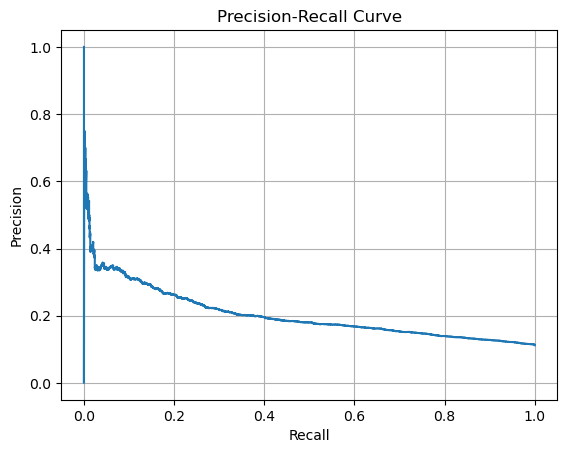

In [35]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


<Figure size 1000x600 with 0 Axes>

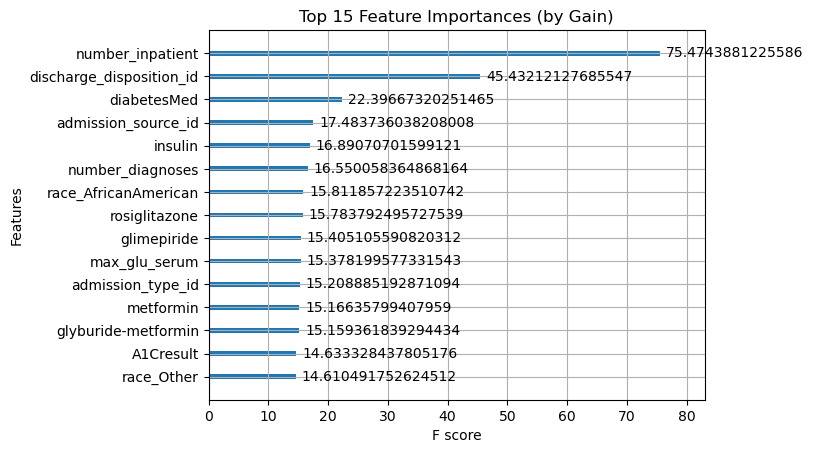

In [36]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=15, importance_type='gain')  # or 'weight' or 'cover'
plt.title("Top 15 Feature Importances (by Gain)")
plt.show()


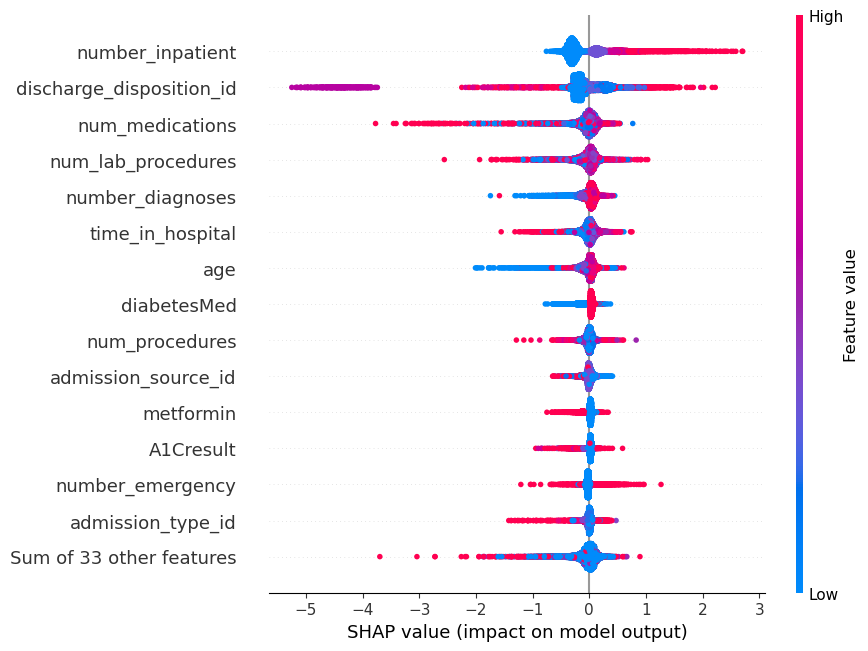

In [37]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=15)
